<a href="https://colab.research.google.com/github/njwbilll/Tugas-5_Grokking-Deep-Learning-MANNING_Najwa-Bilqis-Al-Khalidah/blob/main/08_Learning_Signal_and_Generalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Chapter 8: Learning Signal and Generalization

## Ringkasan Chapter

Pada Chapter 8, fokus pembahasan mulai bergeser dari sekadar membuat neural network belajar menjadi memahami kualitas sinyal pembelajaran yang diterima model.

Bab ini menjelaskan:

1. Learning Signal
2. Generalization
3. Training Error dan Test Error
4. Overfitting
5. Underfitting
6. Validasi Model
7. Noise pada Dataset
8. Evaluasi Kinerja Neural Network
9. Pengaruh Jumlah Data
10. Praktik Eksperimen Menggunakan NumPy

Chapter ini sangat penting karena model yang memiliki error training rendah belum tentu mampu bekerja dengan baik pada data baru.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)



## 1. Apa Itu Generalization

Generalization adalah kemampuan model untuk bekerja dengan baik pada data yang belum pernah dilihat sebelumnya.

Tujuan utama machine learning bukan menghafal data training.

Tujuan sebenarnya adalah menghasilkan prediksi yang akurat pada data baru.

Model yang mampu melakukan hal tersebut dikatakan memiliki generalization yang baik.


In [2]:

x_train = np.array([1,2,3,4,5])
y_train = np.array([2,4,6,8,10])

print("Training Data")
print(x_train)
print(y_train)


Training Data
[1 2 3 4 5]
[ 2  4  6  8 10]



## 2. Learning Signal

Learning signal adalah informasi yang diperoleh model dari error.

Jika prediksi salah, error memberikan petunjuk bagaimana bobot harus diperbaiki.

Semakin jelas sinyal tersebut, semakin cepat model belajar.

Jika data penuh noise, learning signal menjadi lemah.


In [3]:

prediction = 7
target = 10

error = target - prediction

print("Prediction :", prediction)
print("Target     :", target)
print("Error      :", error)


Prediction : 7
Target     : 10
Error      : 3



## 3. Dataset Bersih dan Dataset Berisik

Dataset bersih memiliki pola yang jelas.

Dataset berisik mengandung variasi acak yang tidak berhubungan dengan target.

Noise dapat mengurangi kualitas pembelajaran.


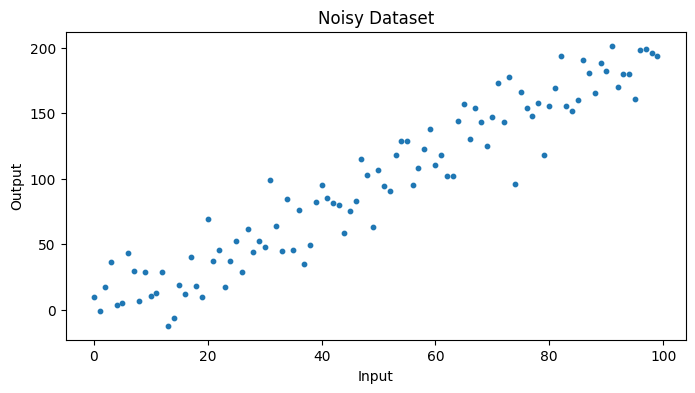

In [4]:

x = np.arange(0,100)

clean_data = 2 * x

noise = np.random.normal(0,20,len(x))

noisy_data = clean_data + noise

plt.figure(figsize=(8,4))
plt.scatter(x,noisy_data,s=10)
plt.title("Noisy Dataset")
plt.xlabel("Input")
plt.ylabel("Output")
plt.show()



## 4. Overfitting

Overfitting terjadi ketika model menghafal data training.

Karakteristik:

1. Error training sangat kecil
2. Error test tinggi
3. Generalisasi buruk

Masalah ini sangat umum pada deep learning.


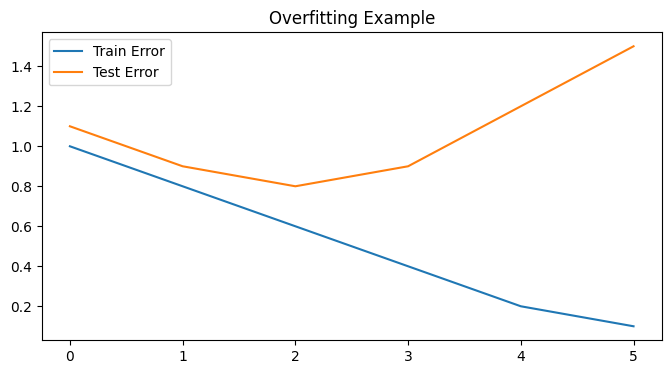

In [5]:

train_error = [1.0,0.8,0.6,0.4,0.2,0.1]
test_error = [1.1,0.9,0.8,0.9,1.2,1.5]

epochs = range(len(train_error))

plt.figure(figsize=(8,4))
plt.plot(epochs, train_error, label="Train Error")
plt.plot(epochs, test_error, label="Test Error")
plt.legend()
plt.title("Overfitting Example")
plt.show()



## 5. Underfitting

Underfitting terjadi ketika model terlalu sederhana.

Karakteristik:

1. Error training tinggi
2. Error test tinggi
3. Pola data belum dipelajari dengan baik

Solusi yang umum:

Menambah kapasitas model atau meningkatkan jumlah iterasi training.



## 6. Training Set dan Test Set

Praktik machine learning yang baik selalu memisahkan data menjadi:

Training Set

Digunakan untuk belajar.

Test Set

Digunakan untuk evaluasi.

Pemisahan ini membantu mengukur kemampuan generalisasi.


In [6]:

data = np.arange(100)

train = data[:80]
test = data[80:]

print("Train Size:", len(train))
print("Test Size :", len(test))


Train Size: 80
Test Size : 20



## 7. Neural Network Sederhana

Pada bagian ini kita membuat model linear sederhana menggunakan gradient descent.


In [7]:

inputs = np.array([1,2,3,4,5])
targets = np.array([2,4,6,8,10])

weight = np.random.randn()

alpha = 0.01

loss_history = []

for epoch in range(200):

    predictions = inputs * weight

    error = predictions - targets

    loss = np.mean(error ** 2)

    gradient = np.mean(2 * error * inputs)

    weight -= alpha * gradient

    loss_history.append(loss)

print("Final Weight:", round(weight,4))


Final Weight: 2.0


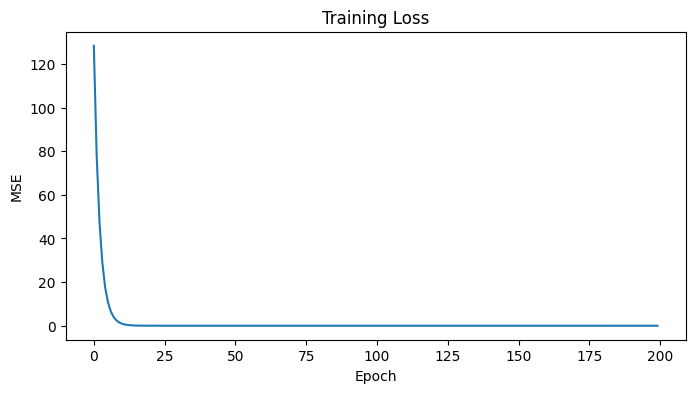

In [8]:

plt.figure(figsize=(8,4))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()



## 8. Pengaruh Jumlah Data

Semakin banyak data berkualitas yang tersedia, semakin mudah model mempelajari pola yang benar.

Namun kualitas data sering lebih penting daripada jumlah data.

Data besar yang penuh noise belum tentu menghasilkan model yang baik.


In [9]:

sizes = [10,50,100,500,1000]

for size in sizes:
    print("Dataset Size:", size)


Dataset Size: 10
Dataset Size: 50
Dataset Size: 100
Dataset Size: 500
Dataset Size: 1000



## 9. Bias dan Variance

Bias tinggi:

Model terlalu sederhana.

Variance tinggi:

Model terlalu sensitif terhadap data training.

Tujuan machine learning adalah menemukan keseimbangan antara bias dan variance.


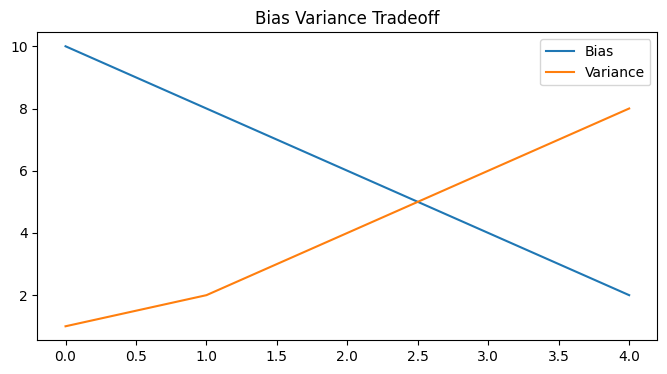

In [10]:

bias = [10,8,6,4,2]
variance = [1,2,4,6,8]

plt.figure(figsize=(8,4))
plt.plot(bias,label="Bias")
plt.plot(variance,label="Variance")
plt.legend()
plt.title("Bias Variance Tradeoff")
plt.show()



## 10. Evaluasi Prediksi

Evaluasi diperlukan untuk mengetahui apakah model benar benar belajar.

Beberapa metrik umum:

1. Mean Squared Error
2. Mean Absolute Error
3. Accuracy
4. Precision
5. Recall

Pada chapter ini fokus utama masih menggunakan Mean Squared Error.


In [11]:

actual = np.array([1,2,3,4])
predicted = np.array([1.2,1.8,2.9,4.3])

mse = np.mean((actual - predicted) ** 2)

print("MSE:", mse)


MSE: 0.04499999999999997



## 11. Eksperimen Generalization

Tujuan eksperimen ini adalah melihat apakah model yang dilatih pada data training dapat menghasilkan prediksi yang masuk akal pada data baru.


In [12]:

new_inputs = np.array([6,7,8])

new_predictions = new_inputs * weight

for inp, pred in zip(new_inputs, new_predictions):
    print("Input:", inp, "Prediction:", round(pred,2))


Input: 6 Prediction: 12.0
Input: 7 Prediction: 14.0
Input: 8 Prediction: 16.0



## 12. Ringkasan Chapter 8

Konsep utama:

1. Generalization lebih penting daripada sekadar menghafal data.
2. Learning signal berasal dari error.
3. Noise dapat mengganggu proses pembelajaran.
4. Overfitting menyebabkan performa buruk pada data baru.
5. Underfitting membuat model gagal memahami pola.
6. Training set dan test set harus dipisahkan.
7. Data berkualitas tinggi menghasilkan model yang lebih baik.
8. Bias dan variance harus seimbang.
9. Evaluasi model merupakan bagian penting dari machine learning.
10. Tujuan akhir adalah membangun model yang mampu bekerja pada data yang belum pernah dilihat sebelumnya.



## Kesimpulan

Chapter 8 memperkenalkan konsep yang sangat penting dalam machine learning modern, yaitu generalization. Sebuah neural network yang baik bukan hanya mampu menghasilkan error kecil pada data training, tetapi juga mampu mempertahankan performa ketika menghadapi data baru. Pemahaman mengenai overfitting, underfitting, learning signal, noise, dan evaluasi model menjadi fondasi bagi chapter chapter selanjutnya yang membahas jaringan yang lebih kompleks.
